# SaaS Product Analytics & Churn Prediction

## 05 — Revenue Analytics

### Objective

Analyze the financial performance of the SaaS platform using subscription and customer revenue data.

This notebook focuses on:

- Monthly Recurring Revenue (MRR)
- Annual Recurring Revenue (ARR)
- Average Revenue Per User (ARPU)
- Month-over-Month revenue growth
- Revenue by subscription plan
- Revenue by billing cycle
- New subscriptions
- Cancellations
- Customer revenue
- Revenue concentration
- Revenue contribution by plan
- Revenue performance trends

### Business Importance

Revenue analysis connects product usage and customer behavior with business performance.

The previous notebooks analyzed:

- Product activity
- Customer funnels
- Retention
- Cohorts

This notebook answers the financial question:

> How is the SaaS business generating and growing recurring revenue?

The business questions documented in `business_questions.md` remain the master framework for this analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:")
print(PROJECT_ROOT)

print("\nAnalytics directory:")
print(ANALYTICS_DIR)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction

Analytics directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\data\analytics


## 2. Load Revenue Analytics

The core revenue calculations were already performed by:

`src/revenue_metrics.py`

This notebook consumes those validated analytical outputs instead of duplicating the same calculations.

This keeps the project architecture clean:

**Python source code → reusable calculations**

**Notebook → analysis, visualization, interpretation**

In [3]:
def load_analytics(filename):
    path = ANALYTICS_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Analytics file not found: {path}"
        )

    return pd.read_csv(path)


monthly_revenue = load_analytics(
    "monthly_revenue_metrics.csv"
)

revenue_by_plan = load_analytics(
    "revenue_by_plan.csv"
)

revenue_by_billing = load_analytics(
    "revenue_by_billing_cycle.csv"
)

new_subscriptions = load_analytics(
    "new_subscriptions.csv"
)

cancellations = load_analytics(
    "cancellations.csv"
)

customer_revenue = load_analytics(
    "customer_revenue.csv"
)

revenue_concentration = load_analytics(
    "revenue_concentration.csv"
)

plan_summary = load_analytics(
    "plan_summary.csv"
)

print("Revenue datasets loaded successfully.")

Revenue datasets loaded successfully.


In [4]:
print("Monthly revenue columns:")
print(monthly_revenue.columns.tolist())

print("\nRevenue by plan columns:")
print(revenue_by_plan.columns.tolist())

print("\nCustomer revenue columns:")
print(customer_revenue.columns.tolist())

Monthly revenue columns:
['month', 'mrr', 'active_customers', 'active_subscriptions', 'arr', 'arpu', 'previous_mrr', 'mrr_growth', 'mrr_growth_pct']

Revenue by plan columns:
['month', 'plan', 'mrr', 'customers', 'arpu']

Customer revenue columns:
['user_id', 'total_mrr', 'average_monthly_revenue', 'active_months', 'plans_used', 'estimated_annual_value']


## 3. Prepare Date Fields

Revenue analysis requires consistent monthly dates.

We identify the appropriate month/date column from the generated analytics.

In [5]:
def detect_date_column(df):
    candidates = [
        "month",
        "date",
        "revenue_month",
        "subscription_month",
        "period",
    ]

    for column in candidates:
        if column in df.columns:
            return column

    return None


monthly_date_column = detect_date_column(
    monthly_revenue
)

if monthly_date_column is None:
    raise ValueError(
        "Could not identify monthly revenue date column."
    )

monthly_revenue[
    monthly_date_column
] = pd.to_datetime(
    monthly_revenue[
        monthly_date_column
    ],
    errors="coerce",
)

monthly_revenue["month"] = (
    monthly_revenue[
        monthly_date_column
    ]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    "Detected date column:",
    monthly_date_column
)

print(
    "Revenue period:",
    monthly_revenue["month"].min(),
    "to",
    monthly_revenue["month"].max()
)

Detected date column: month
Revenue period: 2024-01-01 00:00:00 to 2026-07-01 00:00:00


## 4. Revenue KPI Overview

The primary SaaS revenue KPIs are:

### MRR

Monthly Recurring Revenue represents recurring monthly subscription revenue.

### ARR

Annual Recurring Revenue is approximately:

`MRR × 12`

### ARPU

Average Revenue Per User represents average recurring revenue generated per paying customer.

### MRR Growth

Month-over-Month MRR growth measures the rate at which recurring revenue is expanding or contracting.

In [6]:
print("Available monthly revenue metrics:")

display(
    monthly_revenue.head()
)

Available monthly revenue metrics:


,month,mrr,active_customers,active_subscriptions,arr,arpu,previous_mrr,mrr_growth,mrr_growth_pct
0,2024-01-01,"32,847.00",729,729,"394,164.00",45.06,NaN,NaN,NaN
1,2024-02-01,"71,465.00",1681,1681,"857,580.00",42.51,"32,847.00","38,618.00",117.57
2,2024-03-01,"115,556.00",2683,2683,"1,386,672.00",43.07,"71,465.00","44,091.00",61.70
3,2024-04-01,"158,852.00",3685,3685,"1,906,224.00",43.11,"115,556.00","43,296.00",37.47
4,2024-05-01,"200,812.00",4693,4693,"2,409,744.00",42.79,"158,852.00","41,960.00",26.41


In [7]:
revenue_columns = [
    "mrr",
    "monthly_revenue",
    "arr",
    "arpu",
    "mom_growth",
]

available_revenue_columns = [
    column
    for column in revenue_columns
    if column in monthly_revenue.columns
]

print(
    "Available KPI columns:"
)

print(
    available_revenue_columns
)

Available KPI columns:
['mrr', 'arr', 'arpu']


## 5. Latest Revenue Snapshot

The latest available month provides the current financial state of the SaaS platform.

In [9]:
latest_month = (
    monthly_revenue
    .sort_values("month")
    .iloc[-1]
)

print("=" * 60)
print("LATEST SAAS REVENUE SNAPSHOT")
print("=" * 60)

for column in available_revenue_columns:

    print(
        f"{column}: "
        f"{latest_month[column]:,.2f}"
    )

LATEST SAAS REVENUE SNAPSHOT
mrr: 1,161,462.00
arr: 13,937,544.00
arpu: 41.78


## 6. MRR Trend

MRR is one of the most important SaaS financial metrics because it measures predictable recurring revenue.

The trend helps identify:

- Revenue growth
- Revenue stagnation
- Revenue contraction
- Seasonal patterns
- Major changes in recurring revenue

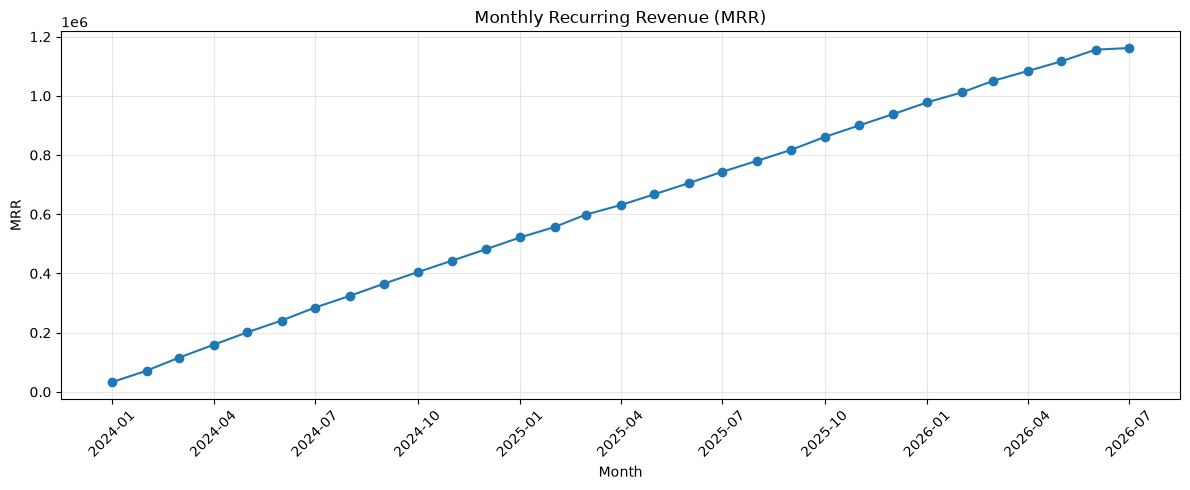

In [10]:
mrr_column = next(
    (
        column
        for column in [
            "mrr",
            "monthly_revenue",
            "monthly_recurring_revenue",
        ]
        if column in monthly_revenue.columns
    ),
    None,
)

if mrr_column is None:
    raise ValueError(
        "MRR column could not be identified."
    )

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    monthly_revenue["month"],
    monthly_revenue[mrr_column],
    marker="o",
)

plt.title(
    "Monthly Recurring Revenue (MRR)"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "MRR"
)

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 7. ARR Trend

ARR provides an annualized view of recurring revenue.

For SaaS businesses, ARR is particularly useful for understanding the scale and trajectory of recurring revenue.

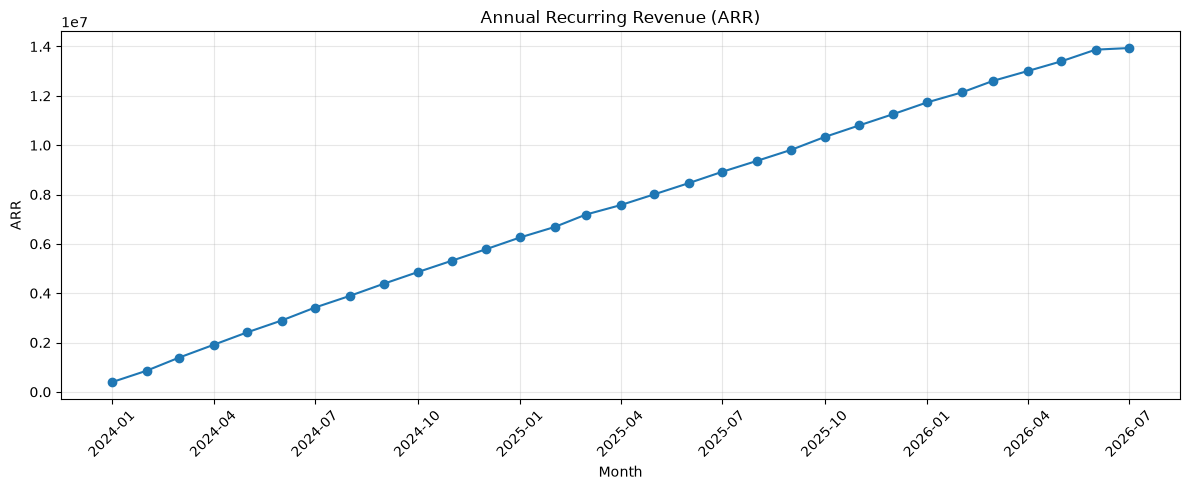

In [11]:
if "arr" in monthly_revenue.columns:

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        monthly_revenue["month"],
        monthly_revenue["arr"],
        marker="o",
    )

    plt.title(
        "Annual Recurring Revenue (ARR)"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "ARR"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 8. MRR Growth

Month-over-Month MRR growth indicates how quickly recurring revenue is changing.

Positive growth indicates expansion.

Negative growth indicates contraction.

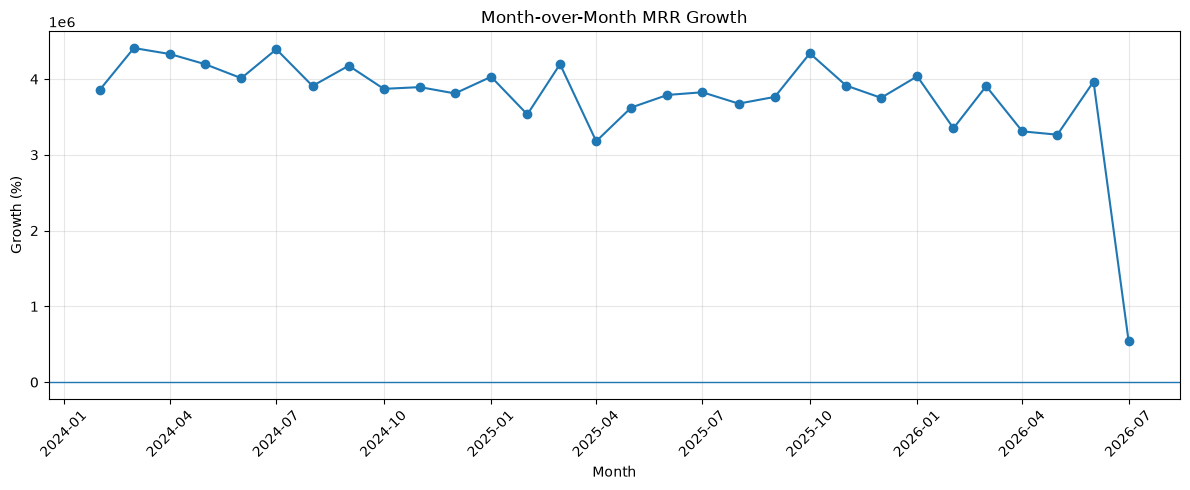

In [12]:
growth_column = next(
    (
        column
        for column in [
            "mom_growth",
            "mrr_growth",
            "revenue_growth",
        ]
        if column in monthly_revenue.columns
    ),
    None,
)

if growth_column:

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        monthly_revenue["month"],
        monthly_revenue[growth_column] * 100,
        marker="o",
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.title(
        "Month-over-Month MRR Growth"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Growth (%)"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 9. Revenue Growth Summary

We identify:

- Average monthly growth
- Highest growth month
- Lowest growth month
- Latest growth rate

In [13]:
if growth_column:

    growth_data = (
        monthly_revenue[
            [
                "month",
                growth_column,
            ]
        ]
        .dropna()
        .copy()
    )

    highest_growth = growth_data.loc[
        growth_data[growth_column].idxmax()
    ]

    lowest_growth = growth_data.loc[
        growth_data[growth_column].idxmin()
    ]

    print(
        f"Average monthly growth: "
        f"{growth_data[growth_column].mean() * 100:.2f}%"
    )

    print(
        f"Highest growth month: "
        f"{highest_growth['month'].strftime('%Y-%m')}"
    )

    print(
        f"Highest growth: "
        f"{highest_growth[growth_column] * 100:.2f}%"
    )

    print(
        f"Lowest growth month: "
        f"{lowest_growth['month'].strftime('%Y-%m')}"
    )

    print(
        f"Lowest growth: "
        f"{lowest_growth[growth_column] * 100:.2f}%"
    )

Average monthly growth: 3762050.00%
Highest growth month: 2024-03
Highest growth: 4409100.00%
Lowest growth month: 2026-07
Lowest growth: 545400.00%


## 10. Revenue by Subscription Plan

Plan-level analysis determines which plans generate the greatest recurring revenue.

This helps answer:

- Which plan contributes the most revenue?
- Which plan has the largest customer base?
- Which plan generates the highest ARPU?
- Is revenue concentrated in premium plans?

In [14]:
display(
    revenue_by_plan
)

,month,plan,mrr,customers,arpu
0,2024-01-01,Professional,"15,563.00",197,79.00
1,2024-01-01,Enterprise,"11,542.00",58,199.00
2,2024-01-01,Starter,"5,742.00",198,29.00
3,2024-01-01,Free,0.00,276,0.00
4,2024-02-01,Professional,"33,101.00",419,79.00
...,...,...,...,...,...
119,2026-06-01,Free,0.00,11888,0.00
120,2026-07-01,Professional,"514,764.00",6516,79.00
121,2026-07-01,Enterprise,"441,581.00",2219,199.00
122,2026-07-01,Starter,"205,117.00",7073,29.00


In [15]:
print(
    "Plan summary:"
)

display(
    plan_summary
)

Plan summary:


,plan,total_mrr,average_mrr,customers,average_arpu
0,Professional,"8,637,070.00",79.00,7271,"1,187.88"
1,Enterprise,"7,297,927.00",199.00,2420,"3,015.67"
2,Starter,"3,467,153.00",29.00,8316,416.93
3,Free,0.00,0.00,11993,0.00


## 11. Plan Revenue Contribution

Revenue contribution is calculated as each plan's share of total recurring revenue.

This allows us to understand the financial importance of each customer segment.

In [16]:
plan_mrr_column = next(
    (
        column
        for column in [
            "total_mrr",
            "mrr",
            "monthly_revenue",
            "total_revenue",
        ]
        if column in revenue_by_plan.columns
    ),
    None,
)

if plan_mrr_column:

    plan_analysis = (
        revenue_by_plan.copy()
    )

    total_plan_revenue = (
        plan_analysis[
            plan_mrr_column
        ].sum()
    )

    plan_analysis[
        "revenue_contribution_pct"
    ] = (
        plan_analysis[
            plan_mrr_column
        ]
        / total_plan_revenue
        * 100
    )

    plan_analysis = (
        plan_analysis
        .sort_values(
            plan_mrr_column,
            ascending=False,
        )
    )

    display(
        plan_analysis
    )

,month,plan,mrr,customers,arpu,revenue_contribution_pct
120,2026-07-01,Professional,"514,764.00",6516,79.00,2.65
116,2026-06-01,Professional,"512,552.00",6488,79.00,2.64
112,2026-05-01,Professional,"495,883.00",6277,79.00,2.56
108,2026-04-01,Professional,"479,767.00",6073,79.00,2.47
104,2026-03-01,Professional,"464,836.00",5884,79.00,2.40
...,...,...,...,...,...,...
99,2026-01-01,Free,0.00,9859,0.00,0.00
115,2026-05-01,Free,0.00,11471,0.00,0.00
111,2026-04-01,Free,0.00,11049,0.00,0.00
119,2026-06-01,Free,0.00,11888,0.00,0.00


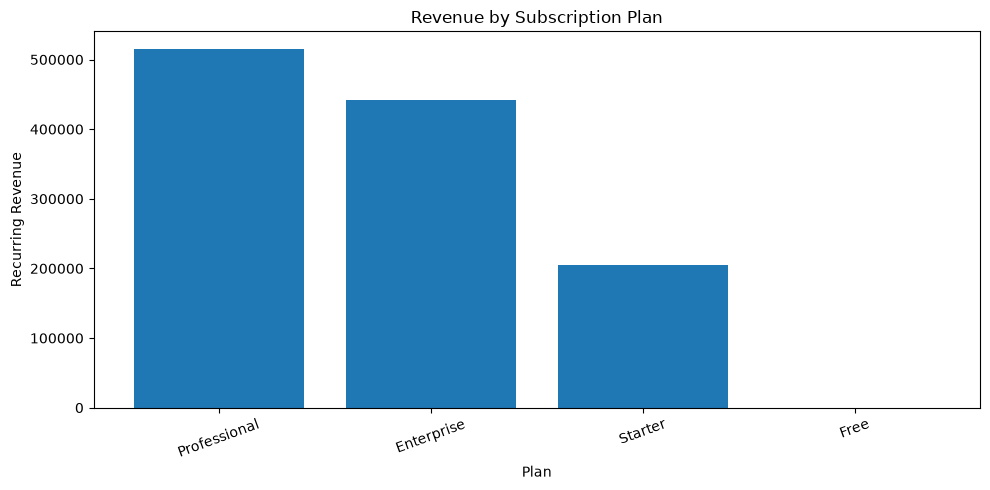

In [17]:
if plan_mrr_column:

    plt.figure(
        figsize=(10, 5)
    )

    plt.bar(
        plan_analysis["plan"],
        plan_analysis[
            plan_mrr_column
        ],
    )

    plt.title(
        "Revenue by Subscription Plan"
    )

    plt.xlabel(
        "Plan"
    )

    plt.ylabel(
        "Recurring Revenue"
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()

    plt.show()

## 12. Plan ARPU

ARPU helps compare the economic value of customers across plans.

A plan with fewer customers can still be strategically important if its average revenue per customer is significantly higher.

In [18]:
if {
    "customers",
    "total_mrr",
}.issubset(
    revenue_by_plan.columns
):

    plan_arpu = (
        revenue_by_plan.copy()
    )

    plan_arpu[
        "calculated_arpu"
    ] = (
        plan_arpu["total_mrr"]
        / plan_arpu["customers"]
    )

    display(
        plan_arpu[
            [
                "plan",
                "customers",
                "total_mrr",
                "calculated_arpu",
            ]
        ]
        .sort_values(
            "calculated_arpu",
            ascending=False,
        )
    )

## 13. Revenue by Billing Cycle

Billing frequency can influence:

- Revenue predictability
- Customer commitment
- Cash-flow characteristics
- Customer retention

We compare monthly and annual billing performance.

In [19]:
display(
    revenue_by_billing
)

,month,billing_cycle,mrr,customers
0,2024-01-01,monthly,"25,487.00",353
1,2024-01-01,annual,"7,360.00",100
2,2024-02-01,monthly,"55,343.00",797
3,2024-02-01,annual,"16,122.00",218
4,2024-03-01,monthly,"89,358.00",1262
...,...,...,...,...
57,2026-05-01,annual,"249,090.00",3340
58,2026-06-01,monthly,"899,356.00",12314
59,2026-06-01,annual,"256,652.00",3448
60,2026-07-01,monthly,"904,466.00",12364


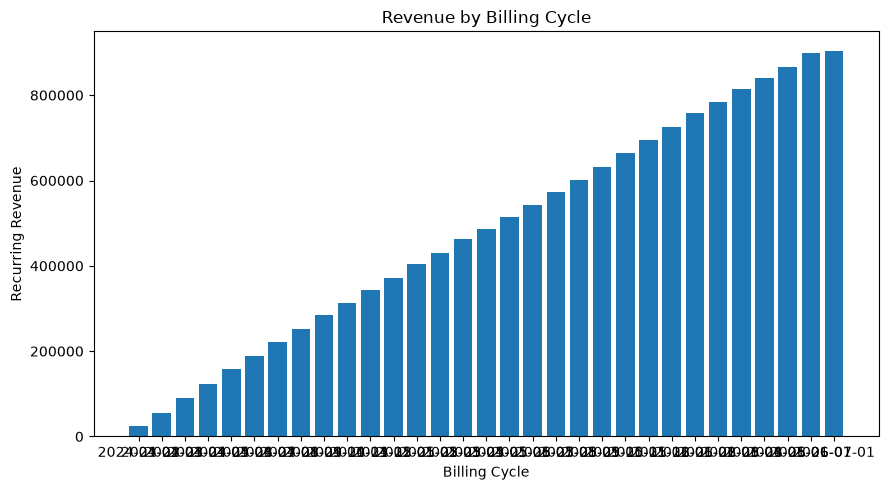

In [20]:
billing_revenue_column = next(
    (
        column
        for column in [
            "total_mrr",
            "mrr",
            "revenue",
            "total_revenue",
        ]
        if column in revenue_by_billing.columns
    ),
    None,
)

if billing_revenue_column:

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        revenue_by_billing[
            revenue_by_billing.columns[
                0
            ]
        ].astype(str),
        revenue_by_billing[
            billing_revenue_column
        ],
    )

    plt.title(
        "Revenue by Billing Cycle"
    )

    plt.xlabel(
        "Billing Cycle"
    )

    plt.ylabel(
        "Recurring Revenue"
    )

    plt.tight_layout()

    plt.show()

## 14. New Subscription Trend

New subscriptions represent customer acquisition from a revenue perspective.

We compare the number of new subscriptions across months.

In [21]:
new_date_column = detect_date_column(
    new_subscriptions
)

if new_date_column:

    new_subscriptions[
        new_date_column
    ] = pd.to_datetime(
        new_subscriptions[
            new_date_column
        ],
        errors="coerce",
    )

display(
    new_subscriptions.head()
)

,month,new_subscriptions,new_customers,new_mrr
0,2024-01-01,729,729,"32,847.00"
1,2024-02-01,952,952,"38,618.00"
2,2024-03-01,1002,1002,"44,091.00"
3,2024-04-01,1008,1008,"43,620.00"
4,2024-05-01,1016,1016,"42,242.00"


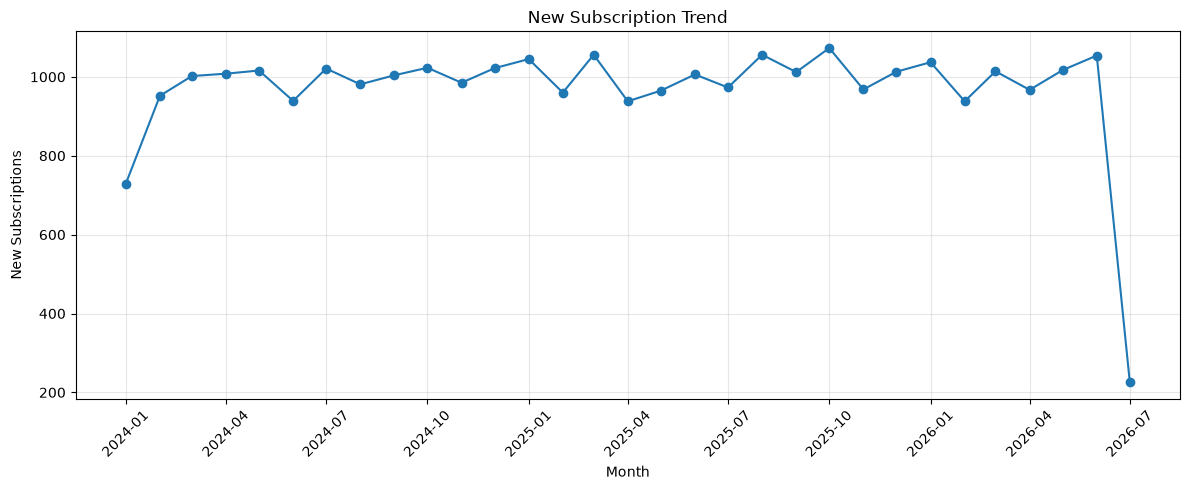

In [22]:
new_count_column = next(
    (
        column
        for column in [
            "new_subscriptions",
            "subscriptions",
            "count",
            "new_customers",
        ]
        if column in new_subscriptions.columns
    ),
    None,
)

if (
    new_date_column
    and new_count_column
):

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        new_subscriptions[
            new_date_column
        ],
        new_subscriptions[
            new_count_column
        ],
        marker="o",
    )

    plt.title(
        "New Subscription Trend"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "New Subscriptions"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 15. Cancellation Trend

New subscriptions show acquisition.

Cancellations show revenue/customer loss.

Comparing both provides a better understanding of subscription momentum.

In [23]:
cancel_date_column = detect_date_column(
    cancellations
)

if cancel_date_column:

    cancellations[
        cancel_date_column
    ] = pd.to_datetime(
        cancellations[
            cancel_date_column
        ],
        errors="coerce",
    )

display(
    cancellations.head()
)

,month,cancellations,cancelled_customers,lost_mrr
0,2024-03-01,6,6,324.00
1,2024-04-01,8,8,282.00
2,2024-05-01,28,28,"1,872.00"
3,2024-06-01,48,48,"2,602.00"
4,2024-07-01,54,54,"3,006.00"


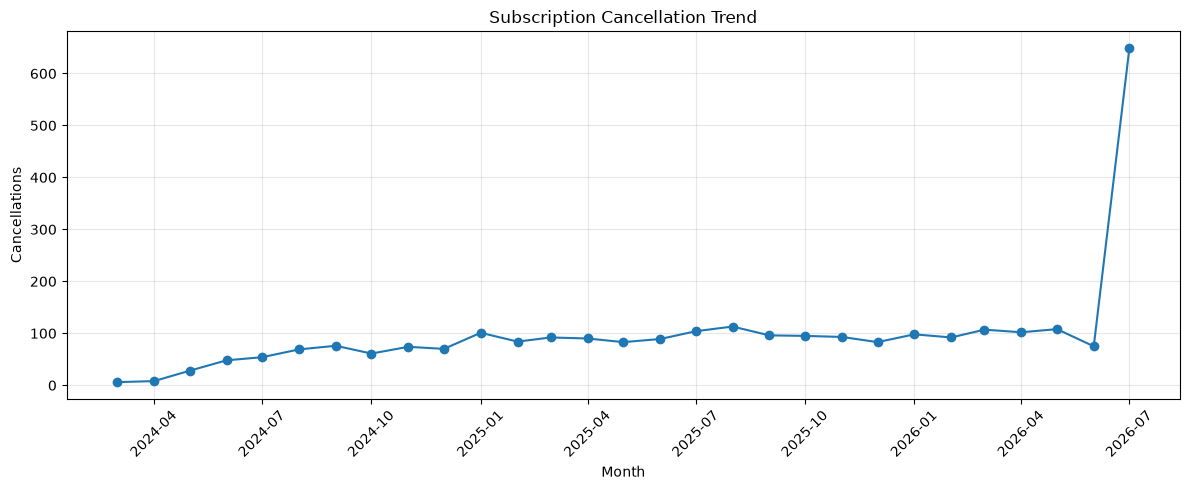

In [24]:
cancel_count_column = next(
    (
        column
        for column in [
            "cancellations",
            "cancelled_subscriptions",
            "count",
            "cancelled_customers",
        ]
        if column in cancellations.columns
    ),
    None,
)

if (
    cancel_date_column
    and cancel_count_column
):

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        cancellations[
            cancel_date_column
        ],
        cancellations[
            cancel_count_column
        ],
        marker="o",
    )

    plt.title(
        "Subscription Cancellation Trend"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Cancellations"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 16. Acquisition vs Cancellation

A useful SaaS growth indicator is the relationship between:

**New subscriptions**

and

**Cancellations**

When new subscriptions consistently exceed cancellations, the customer base has the potential to expand.

When cancellations approach or exceed new subscriptions, growth becomes more difficult to sustain.

In [25]:
if (
    new_date_column
    and new_count_column
    and cancel_date_column
    and cancel_count_column
):

    acquisition = (
        new_subscriptions[
            [
                new_date_column,
                new_count_column,
            ]
        ]
        .rename(
            columns={
                new_date_column: "month",
                new_count_column: "new_subscriptions",
            }
        )
    )

    churn = (
        cancellations[
            [
                cancel_date_column,
                cancel_count_column,
            ]
        ]
        .rename(
            columns={
                cancel_date_column: "month",
                cancel_count_column: "cancellations",
            }
        )
    )

    acquisition["month"] = (
        acquisition["month"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    churn["month"] = (
        churn["month"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    acquisition_vs_cancellation = (
        acquisition.merge(
            churn,
            on="month",
            how="outer",
        )
        .fillna(0)
        .sort_values("month")
    )

    acquisition_vs_cancellation[
        "net_subscription_change"
    ] = (
        acquisition_vs_cancellation[
            "new_subscriptions"
        ]
        -
        acquisition_vs_cancellation[
            "cancellations"
        ]
    )

    display(
        acquisition_vs_cancellation
    )

,month,new_subscriptions,cancellations,net_subscription_change
0,2024-01-01,729,0.00,729.00
1,2024-02-01,952,0.00,952.00
2,2024-03-01,1002,6.00,996.00
3,2024-04-01,1008,8.00,"1,000.00"
4,2024-05-01,1016,28.00,988.00
5,2024-06-01,939,48.00,891.00
6,2024-07-01,1021,54.00,967.00
7,2024-08-01,981,69.00,912.00
8,2024-09-01,1004,76.00,928.00
9,2024-10-01,1023,61.00,962.00


## 17. Customer Revenue Analysis

Customer-level revenue helps identify:

- Highest-value customers
- Average customer revenue
- Revenue concentration
- Potential dependency on a small customer group

In [27]:
display(
    customer_revenue.head(20)
)

,user_id,total_mrr,average_monthly_revenue,active_months,plans_used,estimated_annual_value
0,U013518,"6,169.00",199.00,31,1,"2,388.00"
1,U006791,"6,169.00",199.00,31,1,"2,388.00"
2,U027841,"6,169.00",199.00,31,1,"2,388.00"
3,U023667,"6,169.00",199.00,31,1,"2,388.00"
4,U017027,"6,169.00",199.00,31,1,"2,388.00"
5,U023371,"6,169.00",199.00,31,1,"2,388.00"
6,U025652,"6,169.00",199.00,31,1,"2,388.00"
7,U024732,"6,169.00",199.00,31,1,"2,388.00"
8,U003489,"6,169.00",199.00,31,1,"2,388.00"
9,U027626,"6,169.00",199.00,31,1,"2,388.00"


## 18. Top Revenue Customers

We identify the highest-value customers based on cumulative recurring revenue.

This is useful for customer-success prioritization and revenue-risk analysis.

In [28]:
customer_revenue_column = next(
    (
        column
        for column in [
            "total_mrr",
            "total_revenue",
            "customer_revenue",
            "revenue",
        ]
        if column in customer_revenue.columns
    ),
    None,
)

if customer_revenue_column:

    top_customers = (
        customer_revenue
        .sort_values(
            customer_revenue_column,
            ascending=False,
        )
        .head(20)
    )

    display(
        top_customers
    )

,user_id,total_mrr,average_monthly_revenue,active_months,plans_used,estimated_annual_value
0,U013518,"6,169.00",199.00,31,1,"2,388.00"
1,U006791,"6,169.00",199.00,31,1,"2,388.00"
2,U027841,"6,169.00",199.00,31,1,"2,388.00"
3,U023667,"6,169.00",199.00,31,1,"2,388.00"
4,U017027,"6,169.00",199.00,31,1,"2,388.00"
5,U023371,"6,169.00",199.00,31,1,"2,388.00"
6,U025652,"6,169.00",199.00,31,1,"2,388.00"
7,U024732,"6,169.00",199.00,31,1,"2,388.00"
8,U003489,"6,169.00",199.00,31,1,"2,388.00"
9,U027626,"6,169.00",199.00,31,1,"2,388.00"


## 19. Revenue Concentration

Revenue concentration measures how dependent the SaaS business is on a relatively small number of customers.

A highly concentrated revenue base can create risk because the loss of a few major customers may have a disproportionate financial impact.

In [29]:
display(
    revenue_concentration
)

,user_id,total_mrr,average_monthly_revenue,active_months,plans_used,estimated_annual_value,revenue_share_pct,cumulative_revenue_share_pct,customer_rank
0,U013518,"6,169.00",199.00,31,1,"2,388.00",0.03,0.03,1
1,U006791,"6,169.00",199.00,31,1,"2,388.00",0.03,0.06,2
2,U027841,"6,169.00",199.00,31,1,"2,388.00",0.03,0.10,3
3,U023667,"6,169.00",199.00,31,1,"2,388.00",0.03,0.13,4
4,U017027,"6,169.00",199.00,31,1,"2,388.00",0.03,0.16,5
...,...,...,...,...,...,...,...,...,...
29995,U012191,0.00,0.00,2,1,0.00,0.00,100.00,29996
29996,U000013,0.00,0.00,3,1,0.00,0.00,100.00,29997
29997,U000014,0.00,0.00,30,1,0.00,0.00,100.00,29998
29998,U000015,0.00,0.00,23,1,0.00,0.00,100.00,29999


## 20. Revenue Concentration by Customer Segment

Where concentration metrics are available, we examine:

- Top 1% customers
- Top 5% customers
- Top 10% customers
- Remaining customers

This helps determine whether revenue is broadly distributed or concentrated among a small customer group.

In [30]:
if not customer_revenue.empty:

    concentration_data = (
        customer_revenue[
            [customer_revenue_column]
        ]
        .dropna()
        .sort_values(
            customer_revenue_column,
            ascending=False,
        )
        .reset_index(drop=True)
    )

    total_revenue = (
        concentration_data[
            customer_revenue_column
        ].sum()
    )

    concentration_rows = []

    for percentage in [
        1,
        5,
        10,
        25,
        50,
    ]:

        n = max(
            1,
            int(
                len(concentration_data)
                * percentage
                / 100
            ),
        )

        revenue = (
            concentration_data
            .head(n)[
                customer_revenue_column
            ]
            .sum()
        )

        concentration_rows.append(
            {
                "top_customer_percentage": percentage,
                "customers": n,
                "revenue": revenue,
                "revenue_share_pct":
                    revenue
                    / total_revenue
                    * 100,
            }
        )

    concentration_summary = pd.DataFrame(
        concentration_rows
    )

    display(
        concentration_summary
    )

,top_customer_percentage,customers,revenue,revenue_share_pct
0,1,300,"1,733,091.00",8.93
1,5,1500,"6,208,446.00",32.00
2,10,3000,"9,478,332.00",48.85
3,25,7500,"15,216,949.00",78.43
4,50,15000,"18,979,912.00",97.82


## 21. Revenue Concentration Visualization

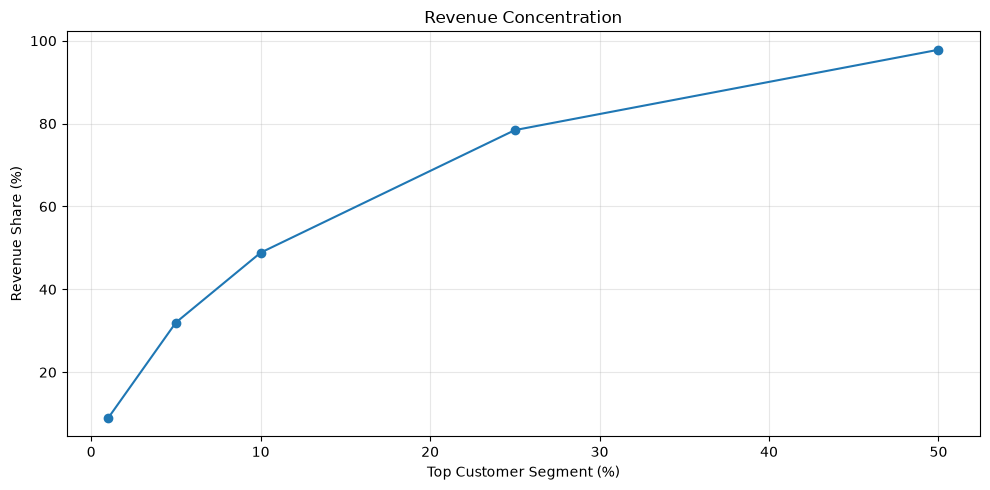

In [31]:
if "concentration_summary" in locals():

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        concentration_summary[
            "top_customer_percentage"
        ],
        concentration_summary[
            "revenue_share_pct"
        ],
        marker="o",
    )

    plt.title(
        "Revenue Concentration"
    )

    plt.xlabel(
        "Top Customer Segment (%)"
    )

    plt.ylabel(
        "Revenue Share (%)"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 22. Revenue Growth Interpretation

Revenue growth should not be evaluated only from the latest month's MRR.

A stronger interpretation considers:

- MRR trend
- ARR trend
- New subscriptions
- Cancellations
- Plan contribution
- Customer revenue concentration

This allows the business to distinguish between:

**Healthy recurring growth**

and

**Growth dependent on a small number of customers or plans.**

## 23. Key Revenue Questions

The analysis contributes to the existing `business_questions.md` framework.

Relevant business areas include:

- What is the current MRR?
- What is the estimated ARR?
- How is recurring revenue changing over time?
- Which plans generate the most revenue?
- Which plans have the highest customer value?
- How many new subscriptions are being added?
- How many subscriptions are being cancelled?
- Is the customer base expanding?
- How concentrated is revenue?
- Which customers contribute the most revenue?
- Is the business dependent on a small group of customers?
- How does billing frequency affect revenue?

## 24. Executive Revenue Summary

The following framework should be used when interpreting the final results:

### Revenue Scale

Current MRR and ARR indicate the current recurring-revenue scale of the business.

### Revenue Growth

MRR growth shows whether the recurring revenue base is expanding or contracting.

### Plan Economics

Plan-level revenue and ARPU identify the most economically important customer segments.

### Customer Acquisition

New subscriptions indicate the rate at which new paying relationships are being created.

### Customer Loss

Cancellations represent a source of revenue and customer-base pressure.

### Revenue Concentration

Concentration analysis identifies potential dependency on high-value customers.

### Strategic Implication

Revenue performance should be interpreted together with the product engagement and retention results from the previous notebooks.

A SaaS business with strong revenue but weak retention may face future growth pressure.

Conversely, strong retention with weak monetization may indicate an opportunity for pricing, packaging, or plan expansion.

## 25. Save Additional Notebook Outputs

In [32]:
ANALYTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if "plan_analysis" in locals():
    plan_analysis.to_csv(
        ANALYTICS_DIR
        / "notebook_plan_revenue_analysis.csv",
        index=False,
    )

if "acquisition_vs_cancellation" in locals():
    acquisition_vs_cancellation.to_csv(
        ANALYTICS_DIR
        / "acquisition_vs_cancellation.csv",
        index=False,
    )

if "concentration_summary" in locals():
    concentration_summary.to_csv(
        ANALYTICS_DIR
        / "notebook_revenue_concentration.csv",
        index=False,
    )

print(
    "Additional revenue analysis outputs saved."
)

Additional revenue analysis outputs saved.


## 26. Final Revenue Summary

In [33]:
print("=" * 70)
print("SAAS REVENUE ANALYTICS — EXECUTIVE SUMMARY")
print("=" * 70)

print(
    f"Latest month: "
    f"{latest_month['month'].strftime('%Y-%m')}"
)

print(
    f"Latest MRR: "
    f"${latest_month[mrr_column]:,.2f}"
)

if "arr" in monthly_revenue.columns:

    print(
        f"Latest ARR: "
        f"${latest_month['arr']:,.2f}"
    )

if "arpu" in monthly_revenue.columns:

    print(
        f"Latest ARPU: "
        f"${latest_month['arpu']:,.2f}"
    )

if growth_column:

    print(
        f"Latest MRR growth: "
        f"{latest_month[growth_column] * 100:.2f}%"
    )

if "customers" in revenue_by_plan.columns:

    print(
        f"Plans analyzed: "
        f"{revenue_by_plan['plan'].nunique():,}"
    )

if customer_revenue_column:

    print(
        f"Customers in revenue analysis: "
        f"{len(customer_revenue):,}"
    )

print("=" * 70)

SAAS REVENUE ANALYTICS — EXECUTIVE SUMMARY
Latest month: 2026-07
Latest MRR: $1,161,462.00
Latest ARR: $13,937,544.00
Latest ARPU: $41.78
Latest MRR growth: 545400.00%
Plans analyzed: 4
Customers in revenue analysis: 30,000


## 27. Conclusion

The revenue analysis connects customer behavior with SaaS financial performance.

The notebook analyzed:

- MRR
- ARR
- ARPU
- MRR growth
- Revenue by plan
- Plan-level ARPU
- Billing-cycle revenue
- New subscriptions
- Cancellations
- Acquisition versus cancellation
- Customer revenue
- Top revenue customers
- Revenue concentration

The findings should be interpreted alongside:

- Product analytics
- Funnel analysis
- Retention analysis

This creates a more complete view of SaaS business performance.

The next stage will focus specifically on customer churn.

---

**Next Notebook:** `06_Churn_Analysis.ipynb`